In [53]:
import numpy as np
import tensorflow as tf
import gymnasium as gym
from collections import deque
import random

In [54]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

State size: 4
Action size: 2


State size: 4
Action size: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)

Episode   1 | Score:  10 | Epsilon: 0.995
Episode   2 | Score:  14 | Epsilon: 0.990
Episode   3 | Score:  11 | Epsilon: 0.985
Episode   4 | Score:  21 | Epsilon: 0.980
Episode   5 | Score:  24 | Epsilon: 0.975
Episode   6 | Score:  14 | Epsilon: 0.970
Episode   7 | Score:  46 | Epsilon: 0.966
Episode   8 | Score:  27 | Epsilon: 0.961
Episode   9 | Score:  48 | Epsilon: 0.956
Episode  10 | Score:  16 | Epsilon: 0.951
Episode  11 | Score:  13 | Epsilon: 0.946
Episode  12 | Score:  11 | Epsilon: 0.942
Episode  13 | Score:  17 | Epsilon: 0.937
Episode  14 | Score:  17 | Epsilon: 0.932
Episode  15 | Score:  10 | Epsilon: 0.928
Episode  16 | Score:  14 | Epsilon: 0.923
Episode  17 | Score:  30 | Epsilon: 0.918
Episode  18 | Score:  37 | Epsilon: 0.914
Episode  19 | Score:  15 | Epsilon: 0.909
Episode  20 | Score:  15 | Epsilon: 0.905
Episode  21 | Score:  23 | Epsilon: 0.900
Episode  22 | Score:  31 | Epsilon: 0.896
Episode  23 | Score:  24 | Epsilon: 0.891
Episode  24 | Score:  27 | Epsilon

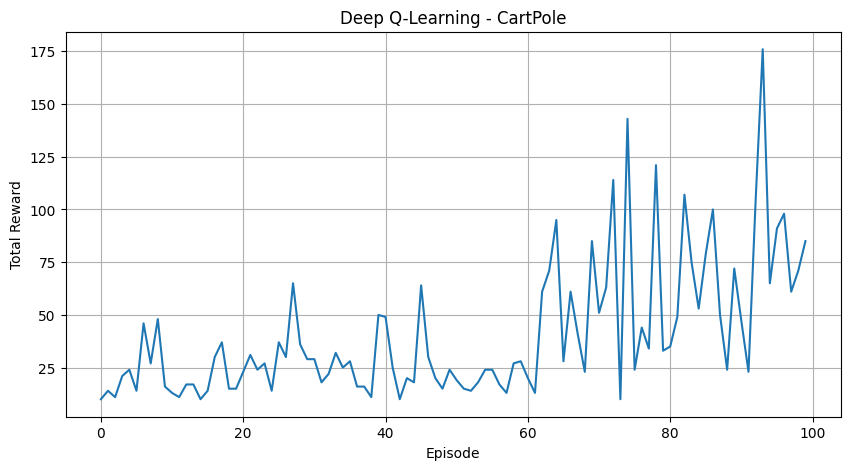

In [56]:
# ============================================================
# 1. Import Libraries
# ============================================================

import numpy as np
import tensorflow as tf
import gymnasium as gym
import random
from collections import deque
import matplotlib.pyplot as plt


# ============================================================
# 2. Create Environment
# ============================================================

env = gym.make("CartPole-v1")

# Get state and action sizes
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print("State size:", state_size)
print("Action size:", action_size)


# ============================================================
# 3. Create Deep Q-Network
# ============================================================

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(state_size,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(action_size, activation="linear")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

model.summary()


# ============================================================
# 4. Replay Memory
# ============================================================

memory = deque(maxlen=2000)


# ============================================================
# 5. Reinforcement Learning Parameters
# ============================================================

gamma = 0.95

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

batch_size = 32


# ============================================================
# 6. Choose Action
# ============================================================

def choose_action(state):

    # Exploration
    if np.random.rand() <= epsilon:
        return random.randrange(action_size)

    # Exploitation
    q_values = model.predict(
        np.expand_dims(state, axis=0),
        verbose=0
    )

    return int(np.argmax(q_values[0]))


# ============================================================
# 7. Train DQN
# ============================================================

def train_model():

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states = np.array([experience[0] for experience in batch])
    actions = np.array([experience[1] for experience in batch])
    rewards = np.array([experience[2] for experience in batch])
    next_states = np.array(
        [experience[3] for experience in batch]
    )
    dones = np.array([experience[4] for experience in batch])

    # Current Q-values
    current_q = model.predict(
        states,
        verbose=0
    )

    # Next Q-values
    next_q = model.predict(
        next_states,
        verbose=0
    )

    targets = current_q.copy()

    for i in range(batch_size):

        if dones[i]:
            targets[i, actions[i]] = rewards[i]

        else:
            targets[i, actions[i]] = (
                rewards[i]
                + gamma * np.max(next_q[i])
            )

    # Train neural network
    model.fit(
        states,
        targets,
        epochs=1,
        verbose=0
    )


# ============================================================
# 8. Train the Agent
# ============================================================

episodes = 100

scores = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0
    done = False

    while not done:

        # Select action
        action = choose_action(state)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Store experience
        memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

        # Update state
        state = next_state

        # Add reward
        total_reward += reward

        # Train model
        train_model()

    # Reduce exploration
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

    scores.append(total_reward)

    print(
        f"Episode {episode + 1:3d} | "
        f"Score: {total_reward:3.0f} | "
        f"Epsilon: {epsilon:.3f}"
    )


# ============================================================
# 9. Plot Training Results
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(scores)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Deep Q-Learning - CartPole")

plt.grid(True)

plt.show()


# ============================================================
# 10. Close Environment
# ============================================================

env.close()

In [57]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [58]:
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)

In [66]:
num_episodes = 5000
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

In [67]:
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True


def choose_action(state):
    if np.random.random() < epsilon:
        return np.random.randint(len(actions))
    else:
        return np.argmax(Q[state])

In [68]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state = start
    total_rewards = 0
    done = False

    while not done:
        action_index = choose_action(state)
        action = actions[action_index]

        next_state = (state[0] + action[0], state[1] + action[1])

        if not is_valid(next_state):
            reward = reward_fire
            done = True
        elif next_state == goal:
            reward = reward_goal
            done = True
        else:
            reward = reward_step

        old_value = Q[state][action_index]
        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0

        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)

        state = next_state
        total_rewards += reward

    global epsilon
    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards)

In [69]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                    next_state not in visited):

                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path


optimal_path = get_optimal_path(Q, start, goal, actions, maze)

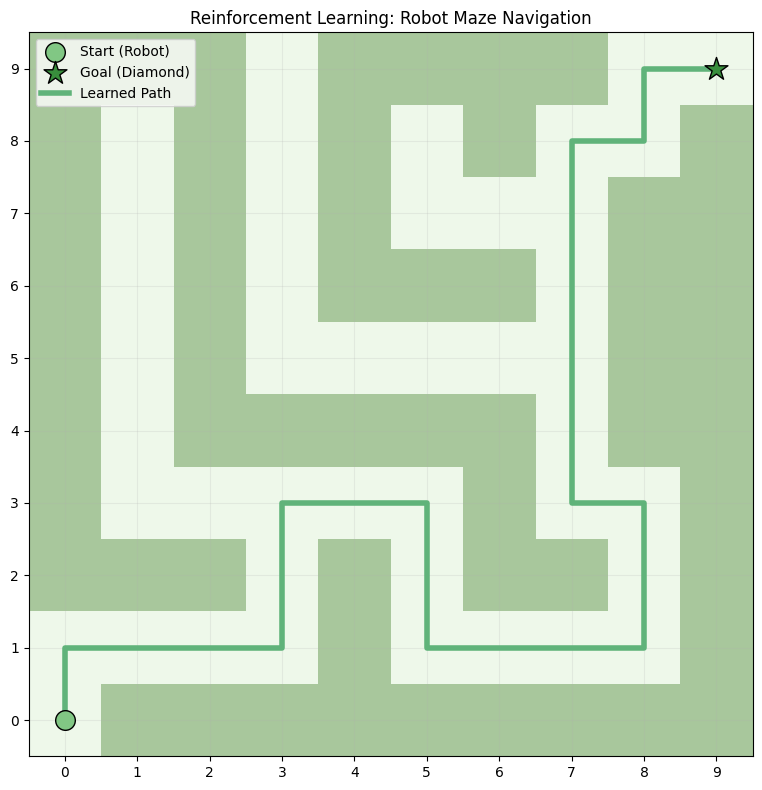

In [70]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_maze_with_path(optimal_path)

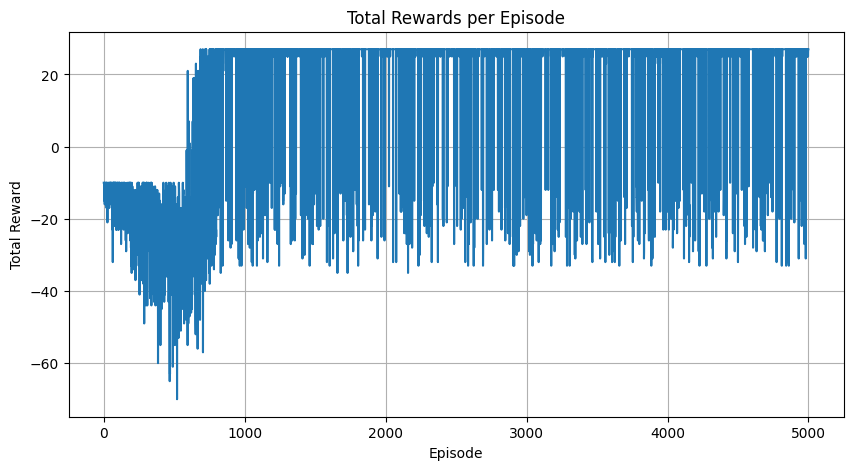

In [71]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title('Total Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    plt.show()


plot_rewards(rewards_all_episodes)